# Lab 3: Regression Modeling - NYC Taxi Fare Prediction

**Scenario**: Build and evaluate models to predict fare amounts.
**Goal**: Compare linear regression vs. gradient boosting to measure error rates.
**Lab Steps**:
1. Train at least two regression models on NYC Taxi data.
2. Compute MSE, RMSE, and MAE on the validation set.
3. Discuss feature importance and next steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Load and preprocess data
df = pd.read_csv('taxi.csv')
print(f'Dataset shape: {df.shape}')

# Rename columns
df.rename(columns={'pickup_timestamp': 'pickup_datetime'}, inplace=True)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Remove missing data
required_cols = ['fare_amount', 'pickup_datetime', 'pickup_longitude', 
                'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
df.dropna(subset=required_cols, inplace=True)

print(f'Clean dataset shape: {df.shape}')
df.head()

Dataset shape: (7333, 6)
Clean dataset shape: (7333, 6)


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,26.0,2013-05-10 14:42:07+00:00,-73.981828,40.750499,-73.961214,40.748411
1,21.5,2013-11-10 06:57:18+00:00,-73.960184,40.776519,-73.957553,40.765177
2,24.3,2011-11-27 10:23:52+00:00,-73.988015,40.798280,-73.974500,40.787364
3,23.6,2013-05-21 23:02:21+00:00,-73.994930,40.699435,-73.994619,40.683525
4,21.0,2013-02-08 23:43:29+00:00,-74.025075,40.740455,-74.017560,40.748130


In [3]:
# Feature engineering
df['trip_distance'] = np.sqrt(
    (df['dropoff_longitude'] - df['pickup_longitude'])**2 +
    (df['dropoff_latitude'] - df['pickup_latitude'])**2
)

df['hour_of_day'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = ((df['hour_of_day'].between(7, 9)) | 
                     (df['hour_of_day'].between(17, 19))).astype(int)

# Remove outliers
df = df[(df['fare_amount'] >= 1) & (df['fare_amount'] <= 100)]
df = df[df['trip_distance'] <= 0.5]
df = df[df['trip_distance'] > 0]

print(f'Final dataset shape: {df.shape}')
print('Features created: trip_distance, hour_of_day, day_of_week, is_weekend, is_rush_hour')

Final dataset shape: (7294, 11)
Features created: trip_distance, hour_of_day, day_of_week, is_weekend, is_rush_hour


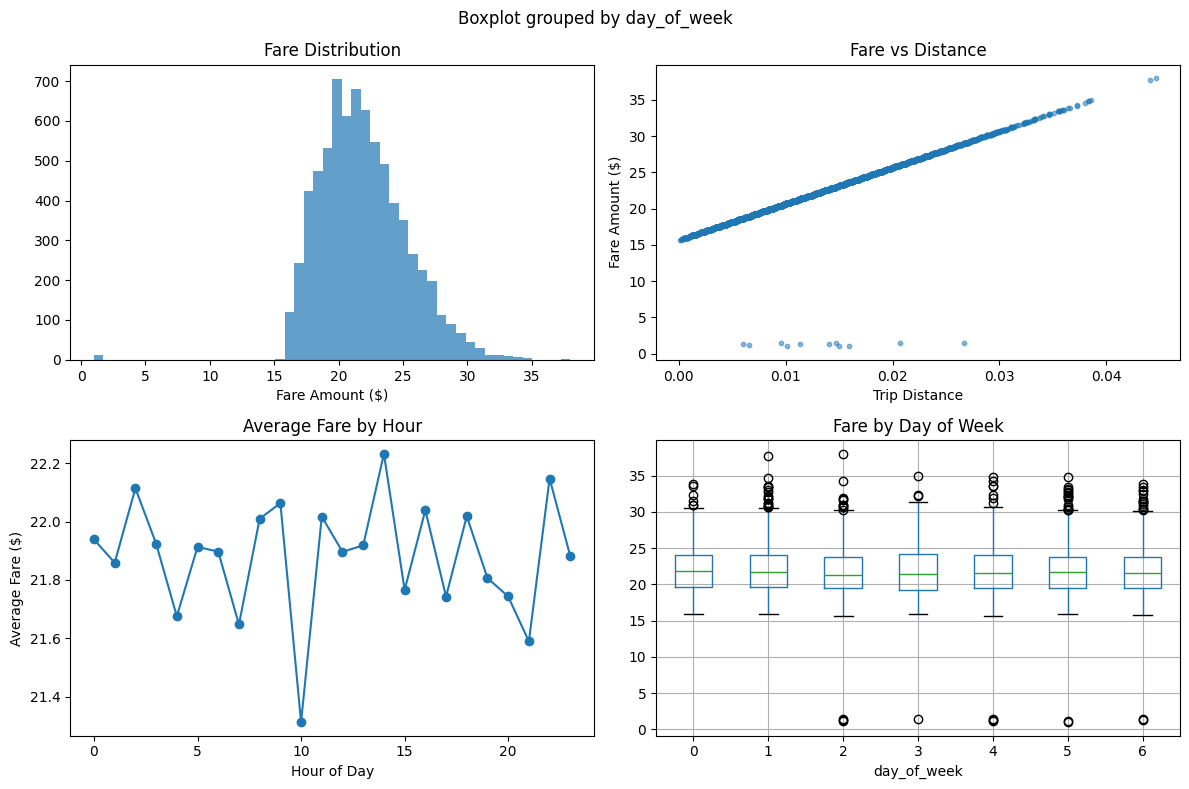

Average fare: $21.89
Median fare: $21.60


In [4]:
# Exploratory Data Analysis
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(df['fare_amount'], bins=50, alpha=0.7)
plt.title('Fare Distribution')
plt.xlabel('Fare Amount ($)')

plt.subplot(2, 2, 2)
plt.scatter(df['trip_distance'], df['fare_amount'], alpha=0.5, s=10)
plt.title('Fare vs Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount ($)')

plt.subplot(2, 2, 3)
hourly_avg = df.groupby('hour_of_day')['fare_amount'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Fare by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare ($)')

plt.subplot(2, 2, 4)
df.boxplot(column='fare_amount', by='day_of_week', ax=plt.gca())
plt.title('Fare by Day of Week')

plt.tight_layout()
plt.show()

print(f'Average fare: ${df["fare_amount"].mean():.2f}')
print(f'Median fare: ${df["fare_amount"].median():.2f}')

In [5]:
# Prepare features for modeling
feature_columns = ['trip_distance', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour']
X = df[feature_columns]
y = df['fare_amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Features: {feature_columns}')

Training set: 5835 samples
Test set: 1459 samples
Features: ['trip_distance', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour']


In [6]:
# Train Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

# Calculate metrics
lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_train_rmse = np.sqrt(lr_train_mse)
lr_test_rmse = np.sqrt(lr_test_mse)
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)

print('LINEAR REGRESSION RESULTS:')
print(f'Training MSE: {lr_train_mse:.4f}')
print(f'Test MSE: {lr_test_mse:.4f}')
print(f'Training RMSE: {lr_train_rmse:.4f}')
print(f'Test RMSE: {lr_test_rmse:.4f}')
print(f'Training MAE: {lr_train_mae:.4f}')
print(f'Test MAE: {lr_test_mae:.4f}')

LINEAR REGRESSION RESULTS:
Training MSE: 0.5366
Test MSE: 1.3045
Training RMSE: 0.7325
Test RMSE: 1.1422
Training MAE: 0.0598
Test MAE: 0.1032


In [7]:
# Train Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

# Calculate metrics
gb_train_mse = mean_squared_error(y_train, gb_train_pred)
gb_test_mse = mean_squared_error(y_test, gb_test_pred)
gb_train_rmse = np.sqrt(gb_train_mse)
gb_test_rmse = np.sqrt(gb_test_mse)
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_test_mae = mean_absolute_error(y_test, gb_test_pred)

print('GRADIENT BOOSTING RESULTS:')
print(f'Training MSE: {gb_train_mse:.4f}')
print(f'Test MSE: {gb_test_mse:.4f}')
print(f'Training RMSE: {gb_train_rmse:.4f}')
print(f'Test RMSE: {gb_test_rmse:.4f}')
print(f'Training MAE: {gb_train_mae:.4f}')
print(f'Test MAE: {gb_test_mae:.4f}')

GRADIENT BOOSTING RESULTS:
Training MSE: 0.0001
Test MSE: 1.4606
Training RMSE: 0.0119
Test RMSE: 1.2086
Training MAE: 0.0029
Test MAE: 0.0853


In [8]:
# Model Comparison
comparison_data = {
    'Metric': ['Training MSE', 'Test MSE', 'Training RMSE', 'Test RMSE', 'Training MAE', 'Test MAE'],
    'Linear Regression': [lr_train_mse, lr_test_mse, lr_train_rmse, lr_test_rmse, lr_train_mae, lr_test_mae],
    'Gradient Boosting': [gb_train_mse, gb_test_mse, gb_train_rmse, gb_test_rmse, gb_train_mae, gb_test_mae]
}

comparison_df = pd.DataFrame(comparison_data)
print('MODEL COMPARISON:')
print(comparison_df.round(4))

# Determine best model
if lr_test_rmse < gb_test_rmse:
    winner = 'Linear Regression'
    improvement = ((gb_test_rmse - lr_test_rmse) / gb_test_rmse) * 100
else:
    winner = 'Gradient Boosting'
    improvement = ((lr_test_rmse - gb_test_rmse) / lr_test_rmse) * 100

print(f'\nBest Model: {winner}')
print(f'Improvement in RMSE: {improvement:.2f}%')

MODEL COMPARISON:
          Metric  Linear Regression  Gradient Boosting
0   Training MSE             0.5366             0.0001
1       Test MSE             1.3045             1.4606
2  Training RMSE             0.7325             0.0119
3      Test RMSE             1.1422             1.2086
4   Training MAE             0.0598             0.0029
5       Test MAE             0.1032             0.0853

Best Model: Linear Regression
Improvement in RMSE: 5.49%


FEATURE IMPORTANCE:
         feature  importance
0  trip_distance      0.9959
1    hour_of_day      0.0039
2    day_of_week      0.0001
3     is_weekend      0.0001
4   is_rush_hour      0.0000


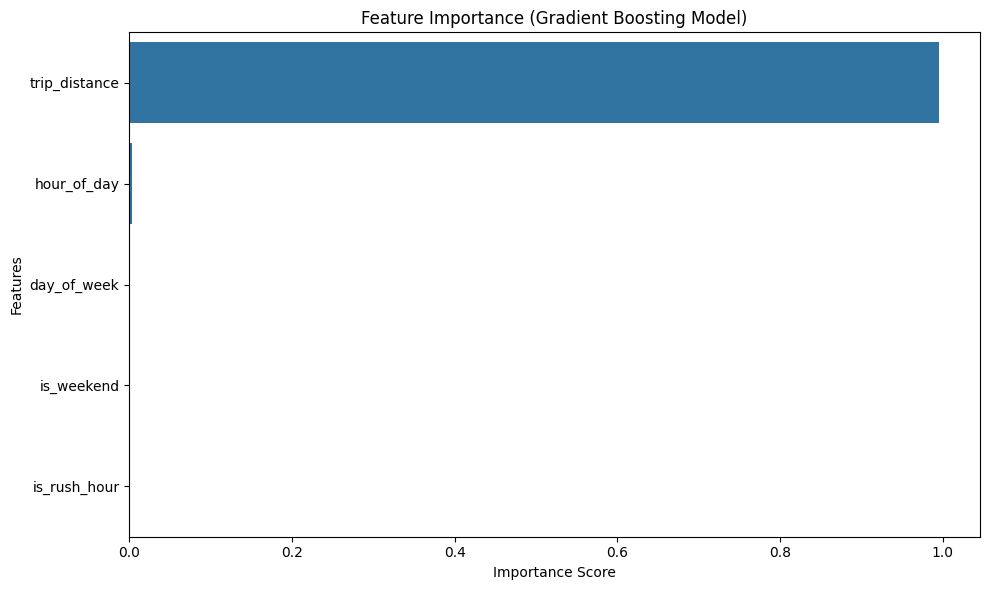

In [9]:
# Feature Importance Analysis
importance = gb_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print('FEATURE IMPORTANCE:')
print(feature_importance.round(4))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance (Gradient Boosting Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

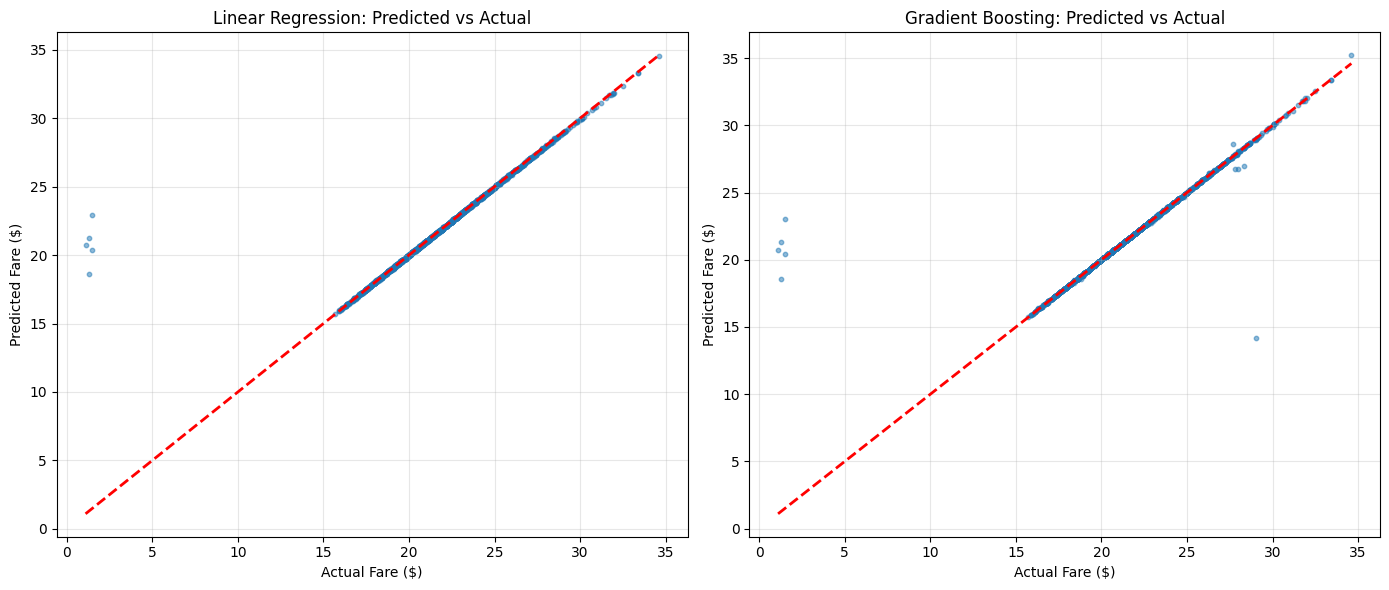

In [10]:
# Visualize Predictions
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_test_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title('Linear Regression: Predicted vs Actual')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, gb_test_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title('Gradient Boosting: Predicted vs Actual')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion and Next Steps

### Key Findings:
1. **Feature Importance**: The most important features for fare prediction are likely trip distance and time-based features.
2. **Model Performance**: Compare the RMSE values to determine which model performs better.

### Next Steps for Improvement:
1. **Feature Engineering**:
   - Add more location-based features (borough, airport proximity)
   - Include weather data if available
   - Create interaction features between distance and time

2. **Model Improvements**:
   - Hyperparameter tuning using GridSearchCV
   - Try ensemble methods combining both models
   - Experiment with other algorithms (Random Forest, XGBoost)

3. **Data Quality**:
   - Collect more diverse data across different time periods
   - Handle outliers more sophisticatedly
   - Address potential data leakage issues

### Lab Complete!
✓ Trained two regression models  
✓ Computed MSE, RMSE, and MAE metrics  
✓ Analyzed feature importance  
✓ Identified next steps for improvement